# pyaugur Quickstart

Python port of [Augur](https://github.com/neurorestore/Augur): cell type prioritization in single-cell data.

Augur trains a classifier to predict condition labels per cell type, then ranks cell types by AUC.

In [1]:
import numpy as np
import pandas as pd
from pyaugur import calculate_auc, select_variance, select_random

## 1. Load Data

Input: expression matrix (genes × cells) + metadata with `cell_type` and `label` columns.

In [2]:
# Load sc_sim dataset (15,697 genes × 600 cells)
expr = pd.read_csv('../tests/sc_sim_expr.csv', index_col=0)
meta = pd.read_csv('../tests/sc_sim_meta.csv', index_col=0)

print(f'Expression: {expr.shape[0]} genes × {expr.shape[1]} cells')
print(f'Metadata columns: {meta.columns.tolist()}')
print(f'Cell types: {meta["cell_type"].value_counts().to_dict()}')
print(f'Labels: {meta["label"].value_counts().to_dict()}')

Expression: 15697 genes × 600 cells
Metadata columns: ['label', 'cell_type']
Cell types: {'CellTypeA': 200, 'CellTypeB': 200, 'CellTypeC': 200}
Labels: {'control': 306, 'treatment': 294}


## 2. Run Augur (Default)

In [3]:
result = calculate_auc(
    expr.values.astype(np.float64),
    meta=meta,
    label_col='label',
    cell_type_col='cell_type',
)

print('AUC per cell type (ranked):')
result['AUC']

AUC per cell type (ranked):


,cell_type,auc
0,CellTypeC,0.982585
1,CellTypeB,0.855068
2,CellTypeA,0.680363


## 3. Inspect Results

In [4]:
# Detailed results: per-subsample, per-fold AUC
results_df = result['results']
print(f'Results shape: {results_df.shape}')
print(f'Columns: {results_df.columns.tolist()}')
results_df.head(10)

Results shape: (900, 6)
Columns: ['cell_type', 'subsample_idx', 'fold', 'metric', 'estimator', 'estimate']


,cell_type,subsample_idx,fold,metric,estimator,estimate
0,CellTypeA,1,1,roc_auc,binary,0.520408
1,CellTypeA,1,1,accuracy,binary,0.500000
2,CellTypeA,1,2,roc_auc,binary,0.702381
3,CellTypeA,1,2,accuracy,binary,0.615385
4,CellTypeA,1,3,roc_auc,binary,0.821429
5,CellTypeA,1,3,accuracy,binary,0.692308
6,CellTypeA,2,1,roc_auc,binary,0.653061
7,CellTypeA,2,1,accuracy,binary,0.642857
8,CellTypeA,2,2,roc_auc,binary,0.345238
9,CellTypeA,2,2,accuracy,binary,0.384615


In [5]:
# Feature importance (random forest)
importance = result['feature_importance']
print(f'Feature importance shape: {importance.shape}')

# Top genes per cell type
for ct in result['AUC']['cell_type']:
    ct_imp = importance[importance['cell_type'] == ct]
    top_genes = ct_imp.groupby('gene')['importance'].mean().nlargest(5)
    print(f'\nTop 5 genes for {ct}:')
    for gene, imp in top_genes.items():
        print(f'  {gene}: {imp:.4f}')

Feature importance shape: (1063800, 5)

Top 5 genes for CellTypeC:
  gene_62: 0.0127
  gene_103: 0.0078
  gene_1697: 0.0068
  gene_1975: 0.0054
  gene_967: 0.0051



Top 5 genes for CellTypeB:
  gene_1766: 0.0064
  gene_1264: 0.0058
  gene_836: 0.0055
  gene_1666: 0.0054
  gene_831: 0.0054



Top 5 genes for CellTypeA:
  gene_861: 0.0053
  gene_676: 0.0049
  gene_310: 0.0049
  gene_1704: 0.0047
  gene_1441: 0.0046


## 4. Feature Selection

In [6]:
# Variance-based feature selection
X = expr.values.astype(np.float64)
print(f'Before variance filter: {X.shape[0]} genes')

X_filtered = select_variance(X, var_quantile=0.5)
print(f'After variance filter:  {X_filtered.shape[0]} genes')

# Random feature selection
X_random = select_random(X_filtered, feature_perc=0.5, rng=np.random.default_rng(42))
print(f'After random filter:    {X_random.shape[0]} genes')

Before variance filter: 15697 genes


After variance filter:  5789 genes
After random filter:    2894 genes


## 5. Custom Parameters

In [7]:
# Fewer subsamples for faster run
result_fast = calculate_auc(
    expr.values.astype(np.float64),
    meta=meta,
    n_subsamples=10,       # Fewer subsamples
    subsample_size=15,     # Smaller subsamples
    folds=3,
    var_quantile=0.5,
    feature_perc=0.5,
    seed=42,
)

print('Fast mode AUC:')
result_fast['AUC']

Fast mode AUC:


,cell_type,auc
0,CellTypeC,0.994667
1,CellTypeB,0.887333
2,CellTypeA,0.570667


In [8]:
# Logistic regression classifier
result_lr = calculate_auc(
    expr.values.astype(np.float64),
    meta=meta,
    classifier='lr',
    n_subsamples=10,
    lr_params={'mixture': 1.0, 'penalty': 1.0},
    seed=42,
)

print('Logistic Regression AUC:')
result_lr['AUC']

C:\Users\17904\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\17904\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\17904\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\17904\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\17904\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

C:\Users\17904\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\17904\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression AUC:


C:\Users\17904\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,cell_type,auc
0,CellTypeB,0.964286
1,CellTypeC,0.933560
2,CellTypeA,0.579932


## 6. Visualization

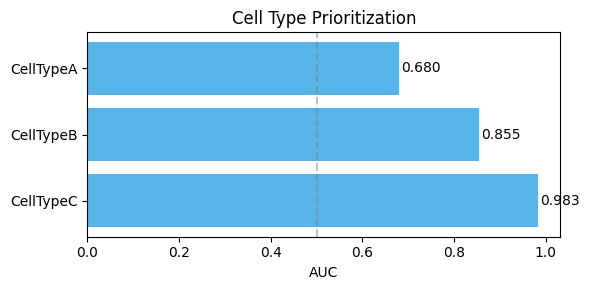

In [9]:
import matplotlib.pyplot as plt

aucs = result['AUC']

fig, ax = plt.subplots(figsize=(6, 3))
y_pos = range(len(aucs))
ax.barh(y_pos, aucs['auc'], color='#56B4E9')
ax.set_yticks(y_pos)
ax.set_yticklabels(aucs['cell_type'])
ax.set_xlabel('AUC')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Cell Type Prioritization')
for i, v in enumerate(aucs['auc']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()